# KDD Cup 2010 Algebra 1 (2005-2006)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = 'algebra_2005_2006_train.txt'
df = pd.read_csv(path, sep='\t', low_memory=False)
print('Shape:', df.shape)
df.head()

Shape: (809694, 19)


,Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,1,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,3(x+2) = 15,2005-09-09 12:24:35.0,2005-09-09 12:24:49.0,2005-09-09 12:25:15.0,2005-09-09 12:25:15.0,40.0,NaN,40.0,0,2,3,1,[SkillRule: Eliminate Parens; {CLT nested; CLT...,1
1,2,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,x+2 = 5,2005-09-09 12:25:15.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,16.0,16.0,NaN,1,0,0,1,"[SkillRule: Remove constant; {ax+b=c, positive...",1~~1
2,3,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,2-8y = -4,2005-09-09 12:25:36.0,2005-09-09 12:25:43.0,2005-09-09 12:26:12.0,2005-09-09 12:26:12.0,36.0,NaN,36.0,0,2,3,1,"[SkillRule: Remove constant; {ax+b=c, positive...",2
3,4,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,-8y = -6,2005-09-09 12:26:12.0,2005-09-09 12:26:34.0,2005-09-09 12:26:34.0,2005-09-09 12:26:34.0,22.0,22.0,NaN,1,0,0,1,"[SkillRule: Remove coefficient; {ax+b=c, divid...",1~~1
4,5,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,2,-7y-5 = -4,2005-09-09 12:26:38.0,2005-09-09 12:28:36.0,2005-09-09 12:28:36.0,2005-09-09 12:28:36.0,118.0,118.0,NaN,1,0,0,1,"[SkillRule: Remove constant; {ax+b=c, positive...",3~~1


## Dataset Overview

In [2]:
display(df.describe(include='all').T)
print(df.dtypes)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row,809694.0,NaN,NaN,NaN,540304.212637,311603.851662,1.0,270798.25,539441.5,809489.75,1080616.0
Anon Student Id,809694,574,l5eh0S53tB,10087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Problem Hierarchy,809694,138,"Unit CTA1_06, Section CTA1_06-2",38336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Problem Name,809694,1084,EG40,24841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Problem View,809694.0,NaN,NaN,NaN,1.692636,1.834555,1.0,1.0,1.0,2.0,49.0
Step Name,809694,187539,R1C1,25986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Step Start Time,808775,674813,2006-05-17 08:52:19.0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First Transaction Time,809694,675453,2006-03-07 10:12:35.0,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Correct Transaction Time,783843,656378,2006-03-24 08:56:21.0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Step End Time,809694,674771,2006-03-24 08:56:21.0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Row                              int64
Anon Student Id                 object
Problem Hierarchy               object
Problem Name                    object
Problem View                     int64
Step Name                       object
Step Start Time                 object
First Transaction Time          object
Correct Transaction Time        object
Step End Time                   object
Step Duration (sec)            float64
Correct Step Duration (sec)    float64
Error Step Duration (sec)      float64
Correct First Attempt            int64
Incorrects                       int64
Hints                            int64
Corrects                         int64
KC(Default)                     object
Opportunity(Default)            object
dtype: object


## Missing Values

In [3]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': 100 * df.isna().sum() / len(df)
}).sort_values('Missing %', ascending=False)

display(missing)

,Missing Count,Missing %
Error Step Duration (sec),621048,76.701569
Opportunity(Default),202669,25.030320
KC(Default),202669,25.030320
Correct Step Duration (sec),189565,23.411931
Correct Transaction Time,25851,3.192688
Step Duration (sec),919,0.113500
Step Start Time,919,0.113500
Problem Hierarchy,0,0.000000
Anon Student Id,0,0.000000
Row,0,0.000000


## Duplicate Records

In [4]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


## Unique-ness (cardinality)

In [5]:
card = []
for c in df.columns:
    card.append([c, df[c].nunique(dropna=True)])
display(pd.DataFrame(card, columns=['Feature','Unique Values']).sort_values('Unique Values', ascending=False))

,Feature,Unique Values
0,Row,809694
7,First Transaction Time,675453
6,Step Start Time,674813
9,Step End Time,674771
8,Correct Transaction Time,656378
5,Step Name,187539
18,Opportunity(Default),107604
10,Step Duration (sec),3056
12,Error Step Duration (sec),2945
3,Problem Name,1084


## Class Balance

Correct First Attempt
1    620642
0    189052
Name: count, dtype: int64
Correct First Attempt
1    76.651426
0    23.348574
Name: count, dtype: float64


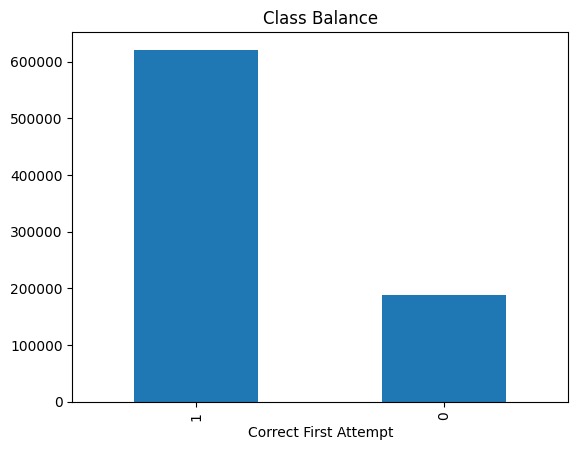

In [6]:
target='Correct First Attempt'
if target in df.columns and df[target].notna().sum()>0:
    counts = df[target].value_counts()
    print(counts)
    print((counts/len(df))*100)
    counts.plot(kind='bar')
    plt.title('Class Balance')
    plt.show()

## Student Activity

count      574.000000
mean      1410.616725
std       1668.433315
min          5.000000
25%        280.500000
50%        722.000000
75%       1683.750000
max      10087.000000
dtype: float64


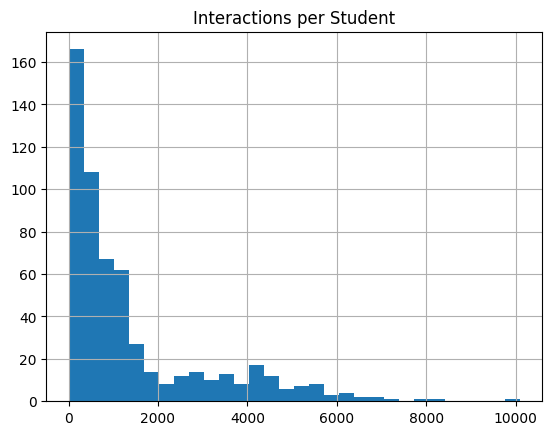

Anon Student Id
02ZjVTxC34    1348
02i5jCrfQK    6654
0493L6bGa9     442
04N6FdP4pd     555
075kbY53c1    5582
dtype: int64


In [7]:
if 'Anon Student Id' in df.columns:
    interactions = df.groupby('Anon Student Id').size()
    print(interactions.describe())
    interactions.hist(bins=30)
    plt.title('Interactions per Student')
    plt.show()
print(interactions.head())

## Skill Analysis

In [8]:
skill_col = 'KC(Default)'

print('Unique Skills:', df[skill_col].nunique())

top_skills = df[skill_col].value_counts().head(5)

display(top_skills)


Unique Skills: 436


KC(Default)
Entering a given                                                                                                                                                                                                                                                                                                                                                                                                                                                     66877
Identifying units                                                                                                                                                                                                                                                                                                                                                                                                                                                    37971
Changing axis bounds                                                  

count    808775.000000
mean         27.744935
std          55.246830
min           0.000000
25%           5.000000
50%          11.000000
75%          27.000000
max        2701.000000
Name: Step Duration (sec), dtype: float64


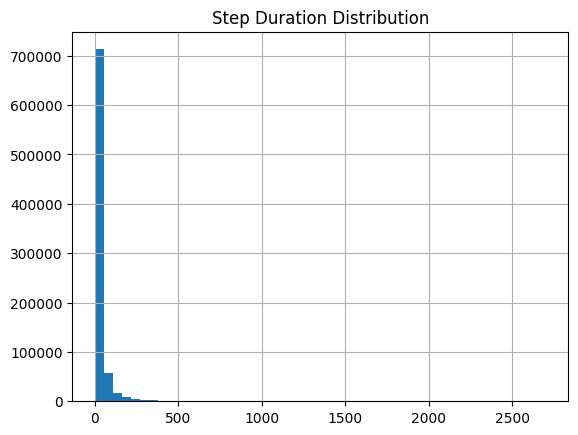

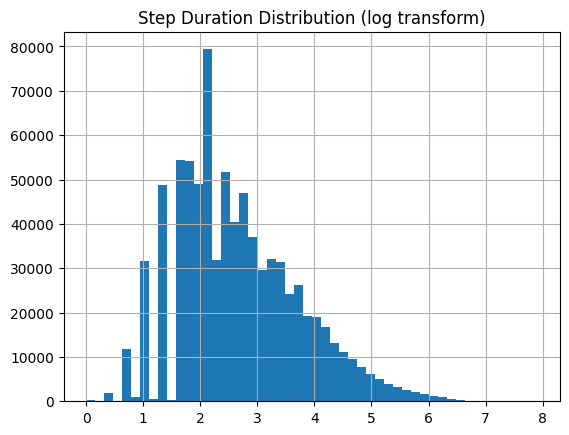

In [9]:
if 'Step Duration (sec)' in df.columns:
    d = pd.to_numeric(df['Step Duration (sec)'], errors='coerce')
    print(d.describe())
    d.hist(bins=50)
    plt.title('Step Duration Distribution')
    plt.show()

if 'Step Duration (sec)' in df.columns:
    d = pd.to_numeric(df['Step Duration (sec)'], errors='coerce')
    d = d[d <= 3600]
    np.log1p(d).hist(bins=50)
    plt.title('Step Duration Distribution (log transform)')
    plt.show()

## Correlation Analysis

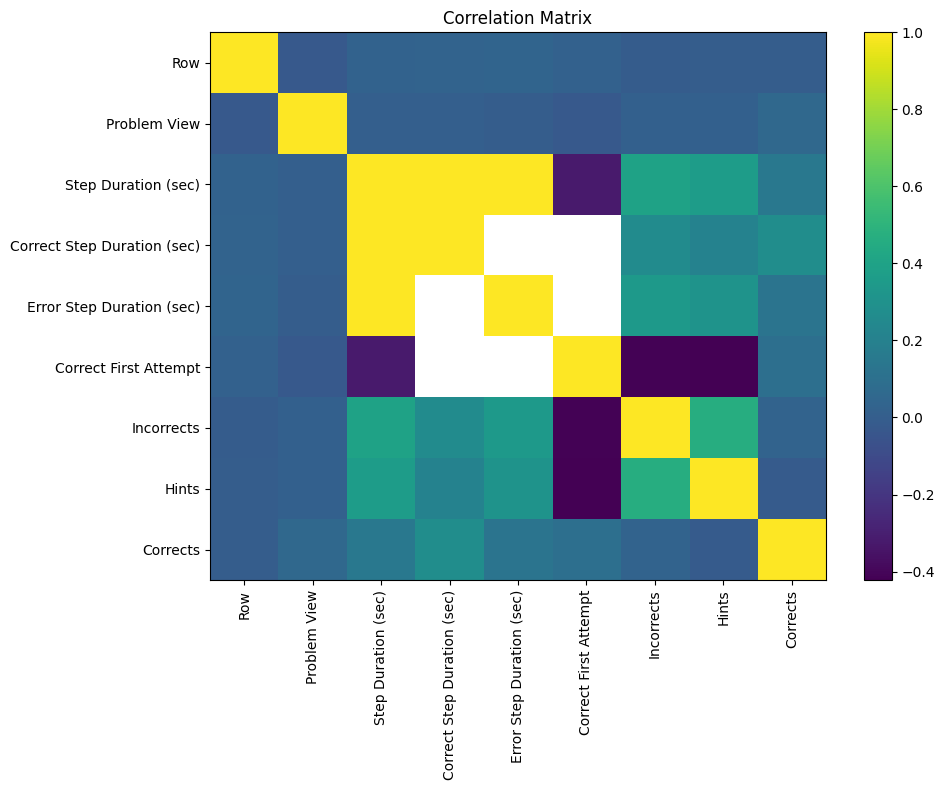

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

if len(num_cols) > 1:

    corr = df[num_cols].corr()

    plt.figure(figsize=(10,8))
    plt.imshow(corr, aspect='auto')
    plt.colorbar()
    plt.title('Correlation Matrix')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.tight_layout()
    plt.show()

## Expected Preprocessing Issues
- Missing KC and duration values
- High-cardinality student/problem/step identifiers
- Multiple skills separated by ~~
- Class imbalance in Correct First Attempt
- Duration outliers
